In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv('superstore sales dataset.csv', encoding='latin-1')
df.head()

,ï»¿Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,8/11/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,8/11/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,12/6/2016,16/6/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,11/10/2015,18/10/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,11/10/2015,18/10/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [5]:
df.shape
df.columns.tolist()
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   ï»¿Row ID      9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

,ï»¿Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


In [7]:
df['Order Date'] = pd.to_datetime(df['Order Date'], dayfirst=True)
df['Ship Date'] = pd.to_datetime(df['Ship Date'], dayfirst=True)

# Confirm the conversion worked
print(df['Order Date'].dtype)
print(df['Ship Date'].dtype)

datetime64[ns]
datetime64[ns]


In [8]:
# Profit margin per order
df['Profit Margin %'] = round((df['Profit'] / df['Sales']) * 100, 2)

# Shipping days (how long from order to delivery)
df['Shipping Days'] = (df['Ship Date'] - df['Order Date']).dt.days

# Order year and month (useful for time series analysis later)
df['Order Year'] = df['Order Date'].dt.year
df['Order Month'] = df['Order Date'].dt.month

# Confirm new columns exist
df[['Sales', 'Profit', 'Profit Margin %', 'Shipping Days', 'Order Year', 'Order Month']].head()

,Sales,Profit,Profit Margin %,Shipping Days,Order Year,Order Month
0,261.9600,41.9136,16.00,3,2016,11
1,731.9400,219.5820,30.00,3,2016,11
2,14.6200,6.8714,47.00,4,2016,6
3,957.5775,-383.0310,-40.00,7,2015,10
4,22.3680,2.5164,11.25,7,2015,10


/var/folders/7d/tclmmn7s5lx06bcft6lv7spw0000gn/T/ipykernel_68475/346229336.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=region_sales, x='Region', y='Sales', palette='Blues_d')


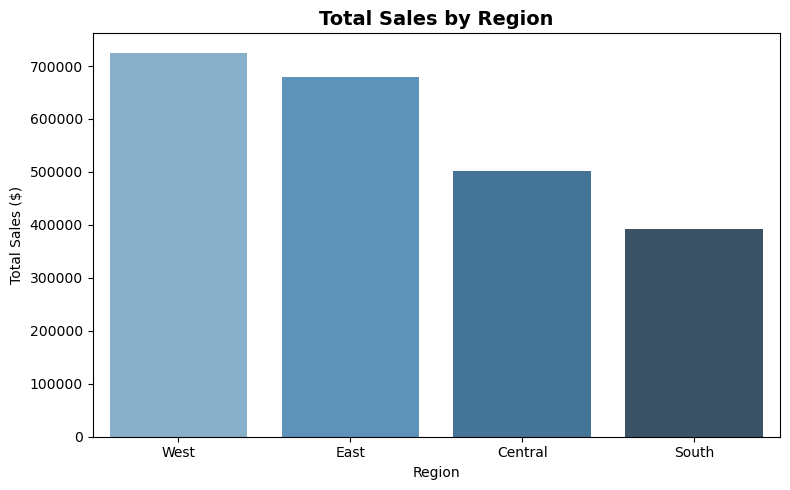

In [9]:
region_sales = df.groupby('Region')['Sales'].sum().sort_values(ascending=False).reset_index()

plt.figure(figsize=(8, 5))
sns.barplot(data=region_sales, x='Region', y='Sales', palette='Blues_d')
plt.title('Total Sales by Region', fontsize=14, fontweight='bold')
plt.xlabel('Region')
plt.ylabel('Total Sales ($)')
plt.tight_layout()
plt.show()

/var/folders/7d/tclmmn7s5lx06bcft6lv7spw0000gn/T/ipykernel_68475/3174258584.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=region_margin, x='Region', y='Profit Margin %', palette=colors)


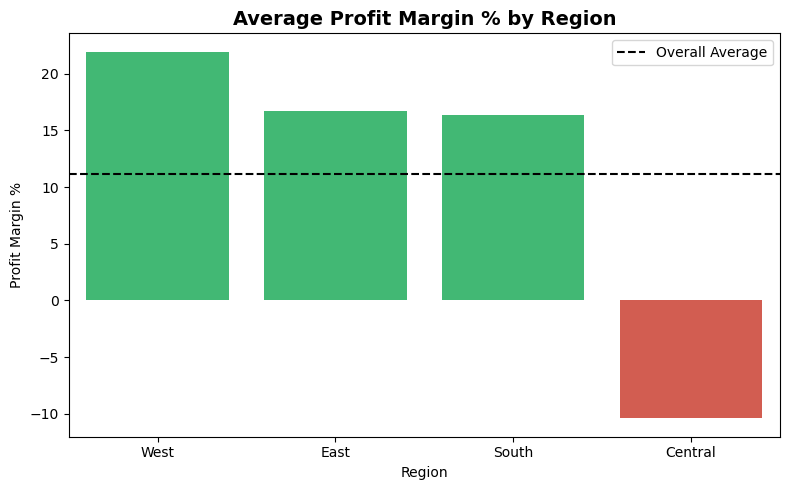

In [10]:
region_margin = df.groupby('Region')['Profit Margin %'].mean().sort_values(ascending=False).reset_index()

plt.figure(figsize=(8, 5))
colors = ['#2ecc71' if x > 10 else '#e74c3c' for x in region_margin['Profit Margin %']]
sns.barplot(data=region_margin, x='Region', y='Profit Margin %', palette=colors)
plt.title('Average Profit Margin % by Region', fontsize=14, fontweight='bold')
plt.xlabel('Region')
plt.ylabel('Profit Margin %')
plt.axhline(y=region_margin['Profit Margin %'].mean(), color='black', linestyle='--', label='Overall Average')
plt.legend()
plt.tight_layout()
plt.show()

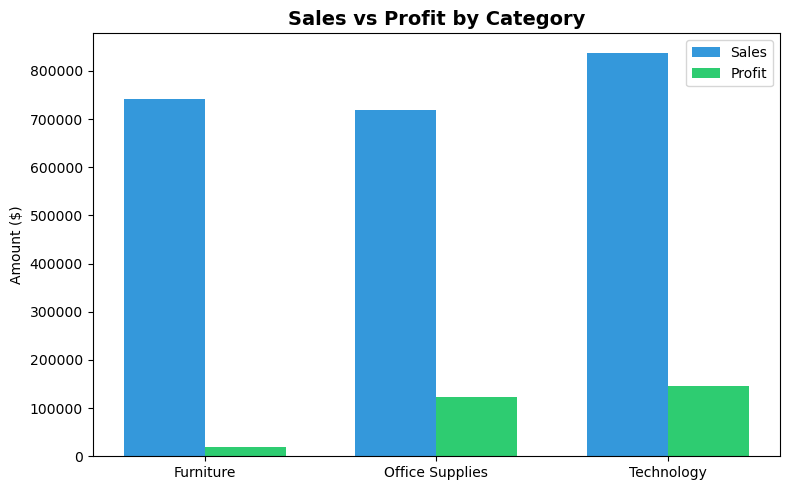

In [11]:
category_summary = df.groupby('Category').agg(
    total_sales=('Sales', 'sum'),
    total_profit=('Profit', 'sum')
).reset_index()

x = range(len(category_summary))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar([i - width/2 for i in x], category_summary['total_sales'], width, label='Sales', color='#3498db')
ax.bar([i + width/2 for i in x], category_summary['total_profit'], width, label='Profit', color='#2ecc71')

ax.set_xticks(x)
ax.set_xticklabels(category_summary['Category'])
ax.set_title('Sales vs Profit by Category', fontsize=14, fontweight='bold')
ax.set_ylabel('Amount ($)')
ax.legend()
plt.tight_layout()
plt.show()

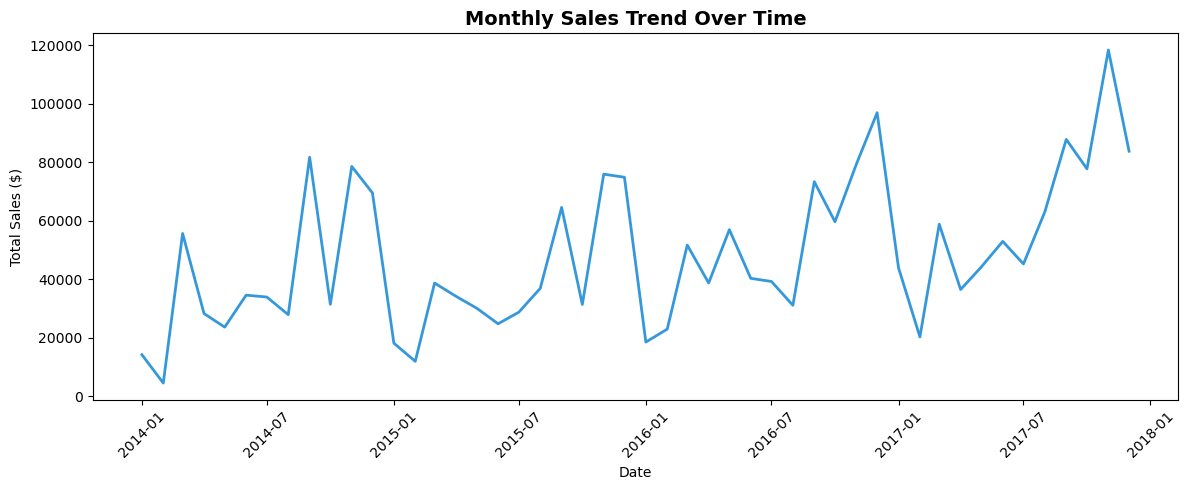

In [13]:
monthly_sales = df.groupby(['Order Year', 'Order Month'])['Sales'].sum().reset_index()
monthly_sales['Date'] = pd.to_datetime({
    'year': monthly_sales['Order Year'],
    'month': monthly_sales['Order Month'],
    'day': 1
})

plt.figure(figsize=(12, 5))
sns.lineplot(data=monthly_sales, x='Date', y='Sales', color='#3498db', linewidth=2)
plt.title('Monthly Sales Trend Over Time', fontsize=14, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Total Sales ($)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Superstore Sales Analysis — Key Findings

**Dataset:** 9,994 orders across 4 regions, 3 categories, 2014–2017

### Finding 1: Regional Profitability Gap
West leads in both sales ($725K) and profit margin (14.94%).
Central ranks 3rd in sales but has the worst margin (7.92%) — 
nearly half of West's despite similar order volumes.

### Finding 2: Discounting is the Root Cause
99% of loss-making orders (1,871 total) carry above-average discounts.
Central discounts ~10% more heavily than other regions, 
directly explaining its margin underperformance.

### Finding 3: Category Performance
Technology leads in sales but Furniture has disproportionately 
low profit relative to its sales — suggesting either high costs 
or heavy discounting at the category level.

### Finding 4: Sales Trend
Monthly sales show seasonal cyclicality with a modest upward 
trend — consistent with a slowly growing retail business.